In [1]:
import os
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 

from sklearn.metrics import classification_report
from TheModel import create_model

2026-05-28 23:08:27.116177: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/coriconsultores/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [35]:
CLIENT_ID = 4

DATA_PATH = f"../data_private/client_{CLIENT_ID}.npz"
TEST_PATH = "../data_private/mnist.npz"

MODEL_OUTPUT_DIR = "local_models"
REPORT_OUTPUT_DIR = "reports"
FIGURE_OUTPUT_DIR = "figures"

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)

In [36]:
client_data = np.load(DATA_PATH)
test_data = np.load(TEST_PATH)

x_train = client_data["x_train"]
y_train = client_data["y_train"]

x_test = test_data["x_test"]
y_test = test_data["y_test"]

print("Datos locales: ", x_train.shape, y_train.shape)
print("Datos de prueba: ", x_test.shape, y_test.shape)

Datos locales:  (11996, 28, 28, 1) (11996,)
Datos de prueba:  (10000, 28, 28, 1) (10000,)


In [37]:
model = tf.keras.models.load_model("initial_global_model.keras")

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5


/Users/coriconsultores/Library/Python/3.9/lib/python/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.7273 - loss: 1.0269 - val_accuracy: 0.1579 - val_loss: 4.4795
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.9564 - loss: 0.1403 - val_accuracy: 0.3171 - val_loss: 2.9701
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9726 - loss: 0.0796 - val_accuracy: 0.9029 - val_loss: 0.2967
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.9852 - loss: 0.0486 - val_accuracy: 0.9721 - val_loss: 0.0905
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.9820 - loss: 0.0507 - val_accuracy: 0.9725 - val_loss: 0.0956


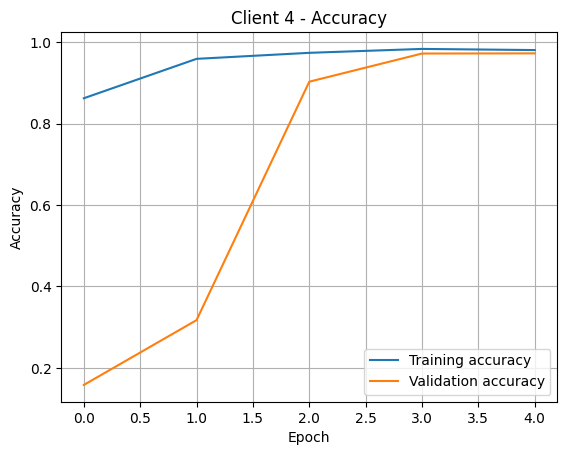

In [38]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Client {CLIENT_ID} - Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{FIGURE_OUTPUT_DIR}/client_{CLIENT_ID}_accuracy.png")
plt.show()

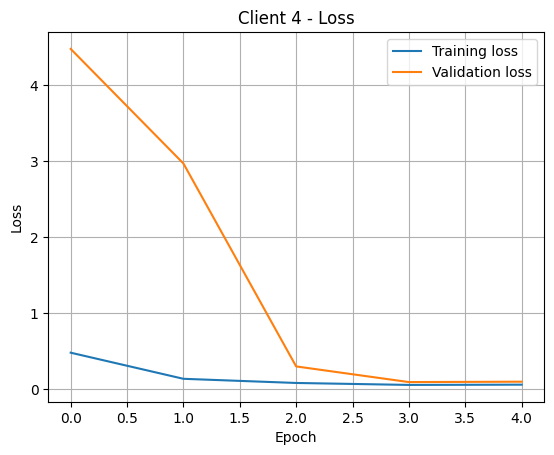

In [39]:
plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Client {CLIENT_ID} - Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{FIGURE_OUTPUT_DIR}/client_{CLIENT_ID}_loss.png")
plt.show()

In [40]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test loss: ", test_loss)
print("Test accuracy: ", test_accuracy)

Test loss:  0.09027361124753952
Test accuracy:  0.9739000201225281


In [41]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_test, y_pred)

print(report)

with open(f"{REPORT_OUTPUT_DIR}/client_{CLIENT_ID}_classification_report.txt", "w") as f:
    f.write(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.94      1.00      0.97      1010
           4       0.96      0.99      0.97       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       1.00      0.91      0.95       974
           9       0.99      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [42]:
model.save(f"{MODEL_OUTPUT_DIR}/client_{CLIENT_ID}.keras")

with open(f"{REPORT_OUTPUT_DIR}/client_{CLIENT_ID}_metrics.txt", "w") as f:
    f.write(f"client_id={CLIENT_ID}\n")
    f.write(f"num_samples={len(x_train)}\n")
    f.write(f"test_loss={test_loss}\n")
    f.write(f"test_accuracy={test_accuracy}\n")

print(f"Modelo local del cliente {CLIENT_ID} guardado.")

Modelo local del cliente 4 guardado.
